In [2]:
import psutil; print(f"{psutil.Process().memory_info().rss / 1e9:.2f} GB")


0.04 GB


# Part 1 
Verification and exploration of the code

In [3]:
import sys, random
import pandas as pd
sys.path.insert(0, '.')

from simulation import *

random.seed(0)

In [4]:
PATIENT_TYPES = {1: 'elective', 2: 'urgent'}
SCAN_TYPES    = {0: 'brain', 1: 'lumbar', 2: 'cervical', 3: 'abdomen', 4: 'other'}
DAYS          = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat'}  # dict!

def patient_repr(p) -> str:
    ptype = PATIENT_TYPES.get(p.patientType, '?')
    stype = SCAN_TYPES.get(p.scanType, '?') if p.patientType == 2 else '-'
    call  = f"W{p.callWeek} {DAYS.get(p.callDay,'?')} {p.callTime:.2f}h"
    appt  = 'unscheduled' if p.scanWeek == -1 else \
            f"W{p.scanWeek} {DAYS.get(p.scanDay,'?')} slot={p.slotNr} @{p.appTime:.2f}h"
    scan  = f"scanTime={p.scanTime:.2f}h" if p.scanTime != -1 else 'not yet scanned'
    tard  = f"tard={p.tardiness*60:+.1f}min"
    ns    = ' NO-SHOW' if p.isNoShow else ''
    return f"[{p.nr:>4}] {ptype:<8} {stype:<8}  arrived: {call:<22}  appt: {appt:<30}  {scan:<22}  {tard}{ns}"

def print_patients(patients, limit=None):
    shown = patients[:limit] if limit else patients
    for p in shown:
        print(patient_repr(p))
    if limit and len(patients) > limit:
        print(f'  ... ({len(patients) - limit} more)')

SLOT_LABELS = {0: '.', 1: 'E', 2: 'U', 3: 'T'}
DAY_NAMES = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']  # renamed to avoid overwriting DAYS dict

def print_week_schedule_compact(sim):
    print(f"{'slot':>4}  {'time':>5}  " + " ".join(f"{d:>3}" for d in DAY_NAMES))
    for s in range(sim.S):
        slot0 = sim.weekSchedule[0][s]
        if not hasattr(slot0, 'startTime'):
            print("weekSchedule not populated yet — call sim.setWeekSchedule() first")
            return
        time_str = f"{slot0.startTime:.2f}h"
        labels = " ".join(f"{SLOT_LABELS.get(sim.weekSchedule[d][s].slotType, '?'):>3}" for d in range(sim.D))
        print(f"{s:>4}  {time_str:>5}  {labels}")


In [5]:
from pathlib import Path

in_path = Path("../input/generated_input_files/input-S1-20.txt")

In [6]:
#set view and seed
n_view = 150
random.seed(0)

#make sim
sim = Simulation(in_path, 100, 100, 4)

#set schedule and visualize
sim.setWeekSchedule()
print_week_schedule_compact(sim)

#need to reset system before generating patients (see main)
sim.resetSystem()

#generate patients and visualize (before and after scheduling)
sim.generatePatients()
print_patients(sim.patients, limit=n_view)
sim.schedulePatients()
print_patients(sim.patients, limit=n_view)

slot   time  Mon Tue Wed Thu Fri Sat
   0  8.00h    E   E   E   E   E   E
   1  8.25h    E   E   E   E   E   E
   2  8.50h    E   E   E   E   E   E
   3  8.75h    E   E   E   E   E   E
   4  9.00h    E   E   E   E   E   E
   5  9.25h    E   E   E   E   E   E
   6  9.50h    E   E   E   E   E   E
   7  9.75h    E   E   E   E   E   E
   8  10.00h    E   E   E   E   E   E
   9  10.25h    E   E   E   E   E   E
  10  10.50h    E   E   E   E   E   E
  11  10.75h    E   E   E   E   E   E
  12  11.00h    E   E   E   E   E   E
  13  11.25h    E   E   E   E   E   E
  14  11.50h    U   U   U   U   U   U
  15  11.75h    U   U   U   U   U   U
  16  13.00h    E   E   E   .   E   .
  17  13.25h    E   E   E   .   E   .
  18  13.50h    E   E   E   .   E   .
  19  13.75h    E   E   E   .   E   .
  20  14.00h    E   E   E   .   E   .
  21  14.25h    E   E   E   .   E   .
  22  14.50h    E   E   E   .   E   .
  23  14.75h    E   E   E   .   E   .
  24  15.00h    E   E   E   .   E   .
  25  15.25h    E   E

In [7]:
overflow = [
    p for p in sim.patients
    if p.patientType == 2
    and p.scanDay in (3, 5)
    and p.appTime != -1
    and p.appTime >= 13
]

print(f"Urgent patients scheduled past 13:00 on Thu/Sat: {len(overflow)}")
print_patients(overflow)


Urgent patients scheduled past 13:00 on Thu/Sat: 34
[ 138] urgent   abdomen   arrived: W0 Sat 10.27h           appt: W0 Sat slot=32 @17.00h          not yet scanned         tard=+0.0min
[ 742] urgent   brain     arrived: W4 Thu 11.87h           appt: W4 Thu slot=32 @17.00h          not yet scanned         tard=+0.0min
[1178] urgent   brain     arrived: W7 Thu 11.89h           appt: W7 Thu slot=32 @17.00h          not yet scanned         tard=+0.0min
[1348] urgent   brain     arrived: W8 Sat 10.92h           appt: W8 Sat slot=32 @17.00h          not yet scanned         tard=+0.0min
[1349] urgent   brain     arrived: W8 Sat 11.15h           appt: W8 Sat slot=33 @17.25h          not yet scanned         tard=+0.0min
[1947] urgent   brain     arrived: W12 Sat 11.76h          appt: W12 Sat slot=32 @17.00h         not yet scanned         tard=+0.0min
[2070] urgent   cervical  arrived: W13 Thu 10.53h          appt: W13 Thu slot=32 @17.00h         not yet scanned         tard=+0.0min
[2246] urg

# Part 2
Runs some initial detailed simulations to get to know the system

In [9]:
def run_simulation_detailed(filename, W, R, rule):
    """
    Same as run_simulation() but saves per-replication and per-week metrics.
    Returns:
        replications: list of dicts, one per replication
        averages: dict of overall averages
    """
    sim = Simulation(filename, W, R, rule)
    sim.setWeekSchedule()

    replications = []

    for r in range(R):
        sim.resetSystem()
        random.seed(r)
        sim.runOneSimulation()

        ov = sim.avgElectiveAppWT * sim.weightEl + sim.avgUrgentScanWt * sim.weightUr

        replications.append({
            'replication':  r,
            'elAppWT':      sim.avgElectiveAppWT,
            'elScanWT':     sim.avgElectiveScanWT,
            'urScanWT':     sim.avgUrgentScanWt,
            'OT':           sim.avgOT,
            'OV':           ov,
            # week-by-week moving averages within this replication:
            'movAvg_elAppWT':  sim.movingAvgElectiveAppWT[:],
            'movAvg_elScanWT': sim.movingAvgElectiveScanWT[:],
            'movAvg_urScanWT': sim.movingAvgUrgentScanWT[:],
            'movAvg_OT':       sim.movingAvgOT[:],
        })

    df_rep = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('movAvg')}
                            for r in replications])

    averages = {
        'elAppWT':  df_rep['elAppWT'].mean(),
        'elScanWT': df_rep['elScanWT'].mean(),
        'urScanWT': df_rep['urScanWT'].mean(),
        'OT':       df_rep['OT'].mean(),
        'OV':       df_rep['OV'].mean(),
    }

    return replications, df_rep, averages

In [10]:
in_path = Path("../input/generated_input_files/input-S1-19.txt")

In [11]:
replications, df_rep, averages = \
    run_simulation_detailed(in_path, W=4000, R=5, rule=1)
df_rep.describe()

,replication,elAppWT,elScanWT,urScanWT,OT,OV
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,825.585897,0.084259,2.534379,0.426741,5.195799
std,1.581139,708.345705,0.000342,0.008679,0.008819,4.216108
min,0.000000,318.384104,0.083832,2.527702,0.420489,2.176235
25%,1.000000,497.843962,0.084002,2.529826,0.422235,3.244565
50%,2.000000,507.413727,0.084291,2.530870,0.424036,3.301893
75%,3.000000,740.224497,0.084521,2.534163,0.424703,4.689358
max,4.000000,2064.063195,0.084647,2.549334,0.442241,12.566946


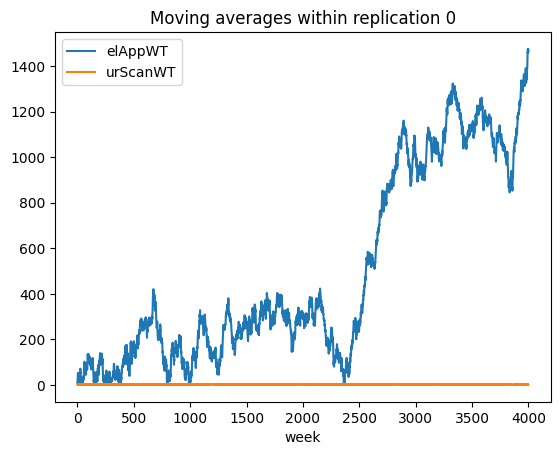

In [12]:
# moving average of one replication (e.g. rep 0) to see warm-up behaviour
import matplotlib.pyplot as plt

i_repl = 0

rep0 = replications[i_repl]
plt.plot(rep0['movAvg_elAppWT'], label='elAppWT')
plt.plot(rep0['movAvg_urScanWT'], label='urScanWT')
plt.xlabel('week')
plt.legend()
plt.title(f'Moving averages within replication {i_repl}')
plt.show()

In [13]:
len(rep0)

10

Data shape: (5, 4000) (replications x weeks), len(data)=5


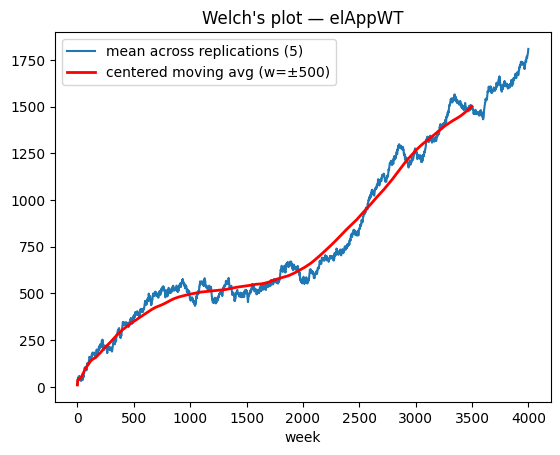

In [14]:
import matplotlib.pyplot as plt
import numpy as np

window = 1000
w = window // 2

# 2D array: shape (n_replications, n_weeks)
data = np.array([r['movAvg_elAppWT'] for r in replications])

print(f"Data shape: {data.shape} (replications x weeks), len(data)={len(data)}")
# Mean across replications at each week
welch = data.mean(axis=0)

n = len(welch)
stop = n - w

welch_ma = np.array([
    welch[i - min(w, i) : i + min(w, i) + 1].mean()
    for i in range(stop)
])

plt.figure()
plt.plot(welch, label=f'mean across replications ({len(data)})')
plt.plot(np.arange(stop), welch_ma, color='red', linewidth=2, label=f'centered moving avg (w=±{w})')
plt.xlabel('week')
plt.title("Welch's plot — elAppWT")
plt.legend()
plt.show()


In [15]:
# now all at the same time,

results = {}

for slot_am in range(10, 19, 2):
    in_path = Path(f"../input/generated_input_files/input-S1-{slot_am}.txt")
    replications, df_rep, averages = \
        run_simulation_detailed(in_path, W=2000,R=10, rule=1)
    results[slot_am] = replications

In [16]:
for slot_am in results:
    for r in results[slot_am]:
        r['movAvg_OV'] = np.array(r['movAvg_elAppWT']) / 168 + np.array(r['movAvg_urScanWT']) / 9


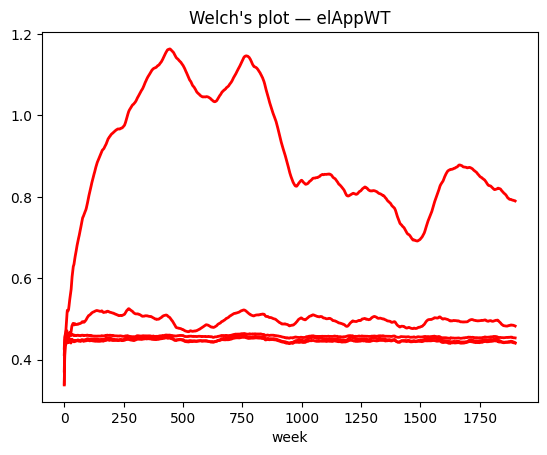

In [17]:
#welch code

attr = 'movAvg_elAppWT'
attr = 'movAvg_OV'

windows = [200]*5
for i_slot, slot_am in enumerate(range(10, 19, 2)):
    replications = results[slot_am]
    # compute movAvg_OV from existing replication data
    window = windows[i_slot]
    w = window // 2
    data = np.array([r[attr] for r in replications])
    welch = data.mean(axis=0)
    n = len(welch)
    stop = n - w
    welch_ma = np.array([
        welch[i - min(w, i) : i + min(w, i) + 1].mean()
        for i in range(stop)
    ])
    #plt.plot(welch, label=f'mean across replications ({len(data)})')
    plt.plot(np.arange(stop), welch_ma, color='red', linewidth=2, label=f'centered moving avg (w=±{w})')
plt.xlabel('week')
plt.title("Welch's plot — elAppWT")
plt.show()



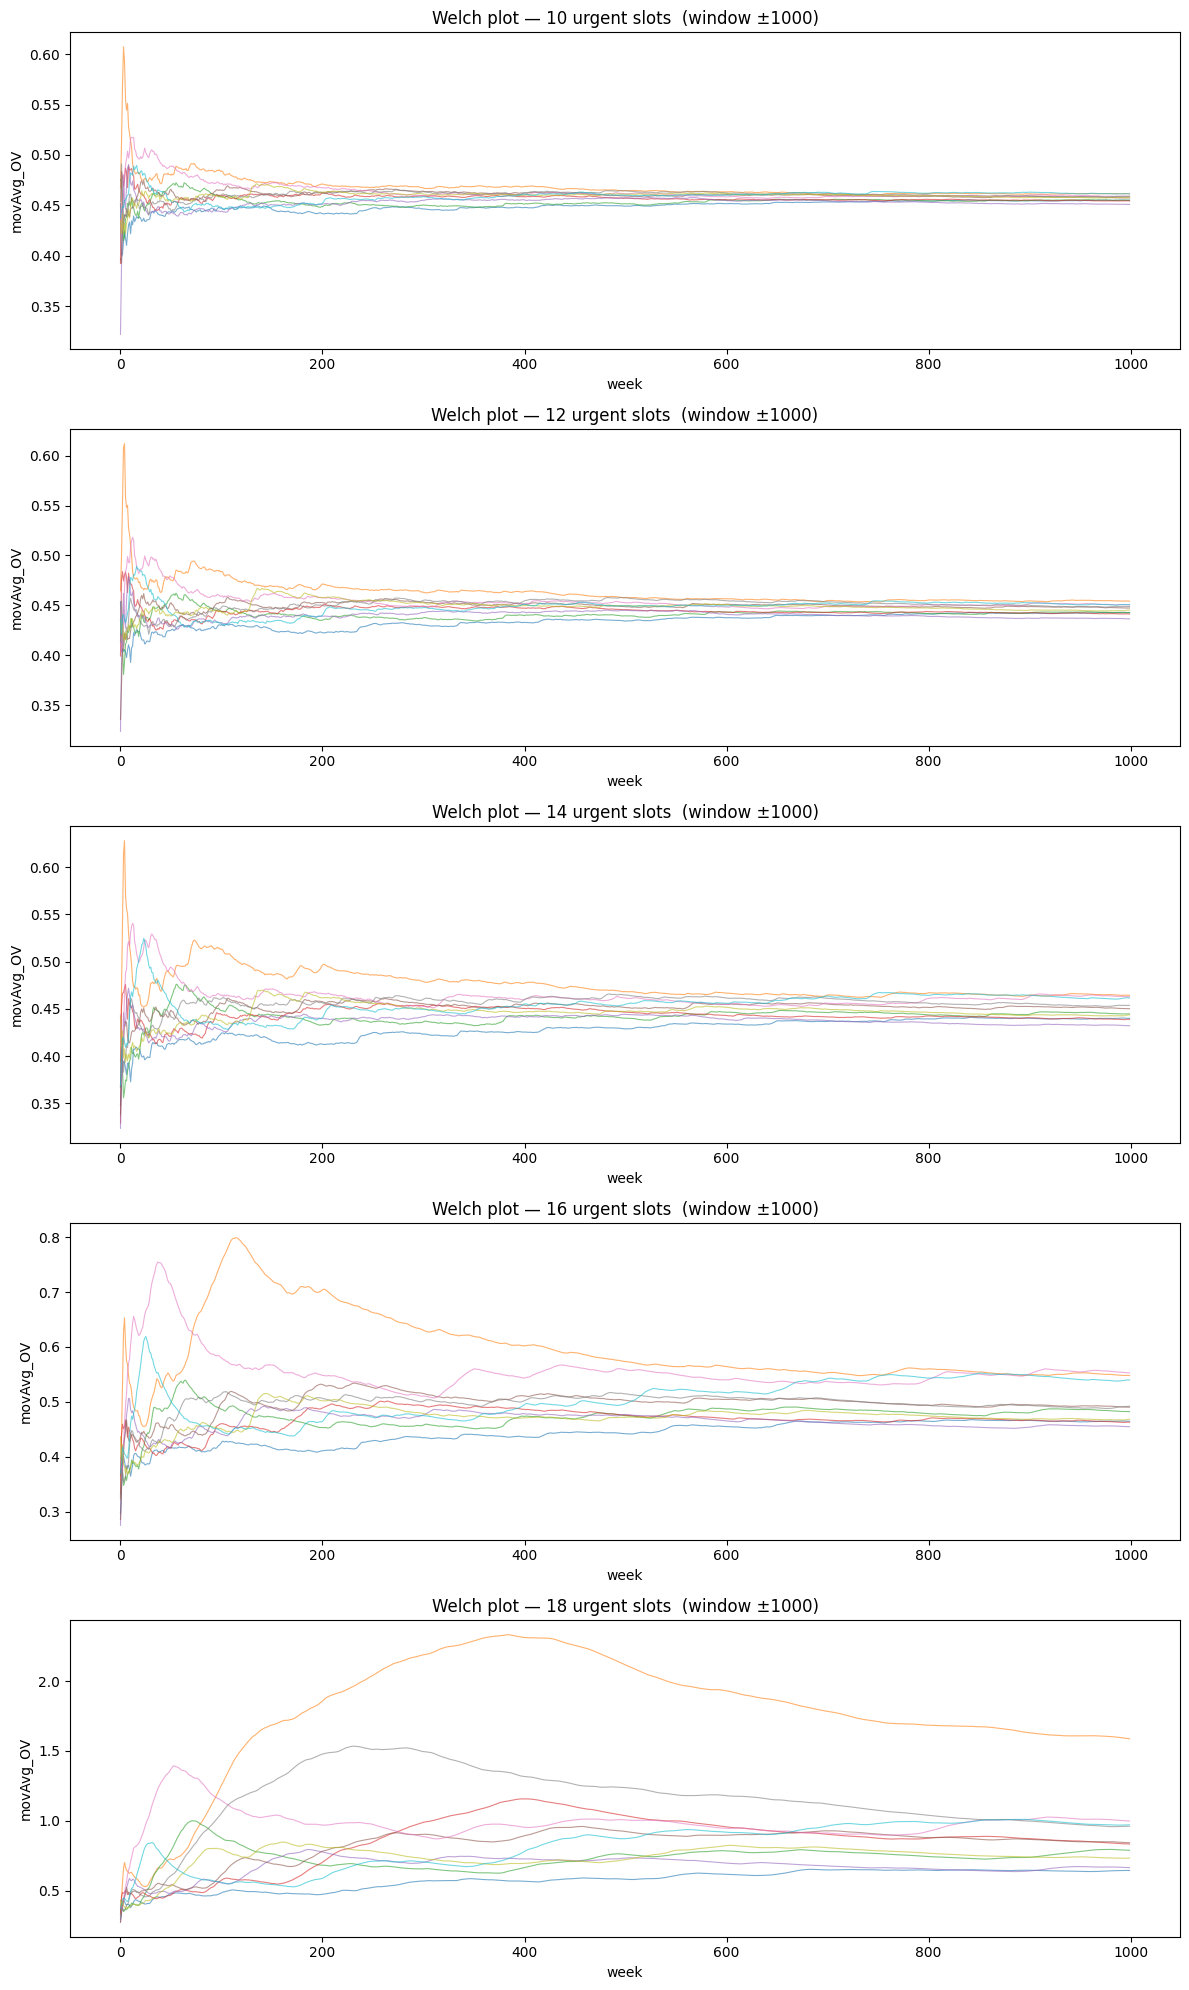

In [19]:
windows = [2000]*5
slots   = list(range(10, 19, 2))

fig, axes = plt.subplots(len(slots), 1, figsize=(12, 4 * len(slots)), sharex=False)

for ax, (i_slot, slot_am) in zip(axes, enumerate(slots)):
    replications = results[slot_am]
    window = windows[i_slot]
    w = window // 2

    for r in replications:
        series = np.array(r[attr])
        n = len(series)
        stop = n - w
        ma = np.array([
            series[i - min(w, i) : i + min(w, i) + 1].mean()
            for i in range(stop)
        ])
        ax.plot(np.arange(stop), ma, linewidth=0.8, alpha=0.6)

    ax.set_title(f'Welch plot — {slot_am} urgent slots  (window ±{w})')
    ax.set_xlabel('week')
    ax.set_ylabel(attr)

plt.tight_layout()
plt.show()


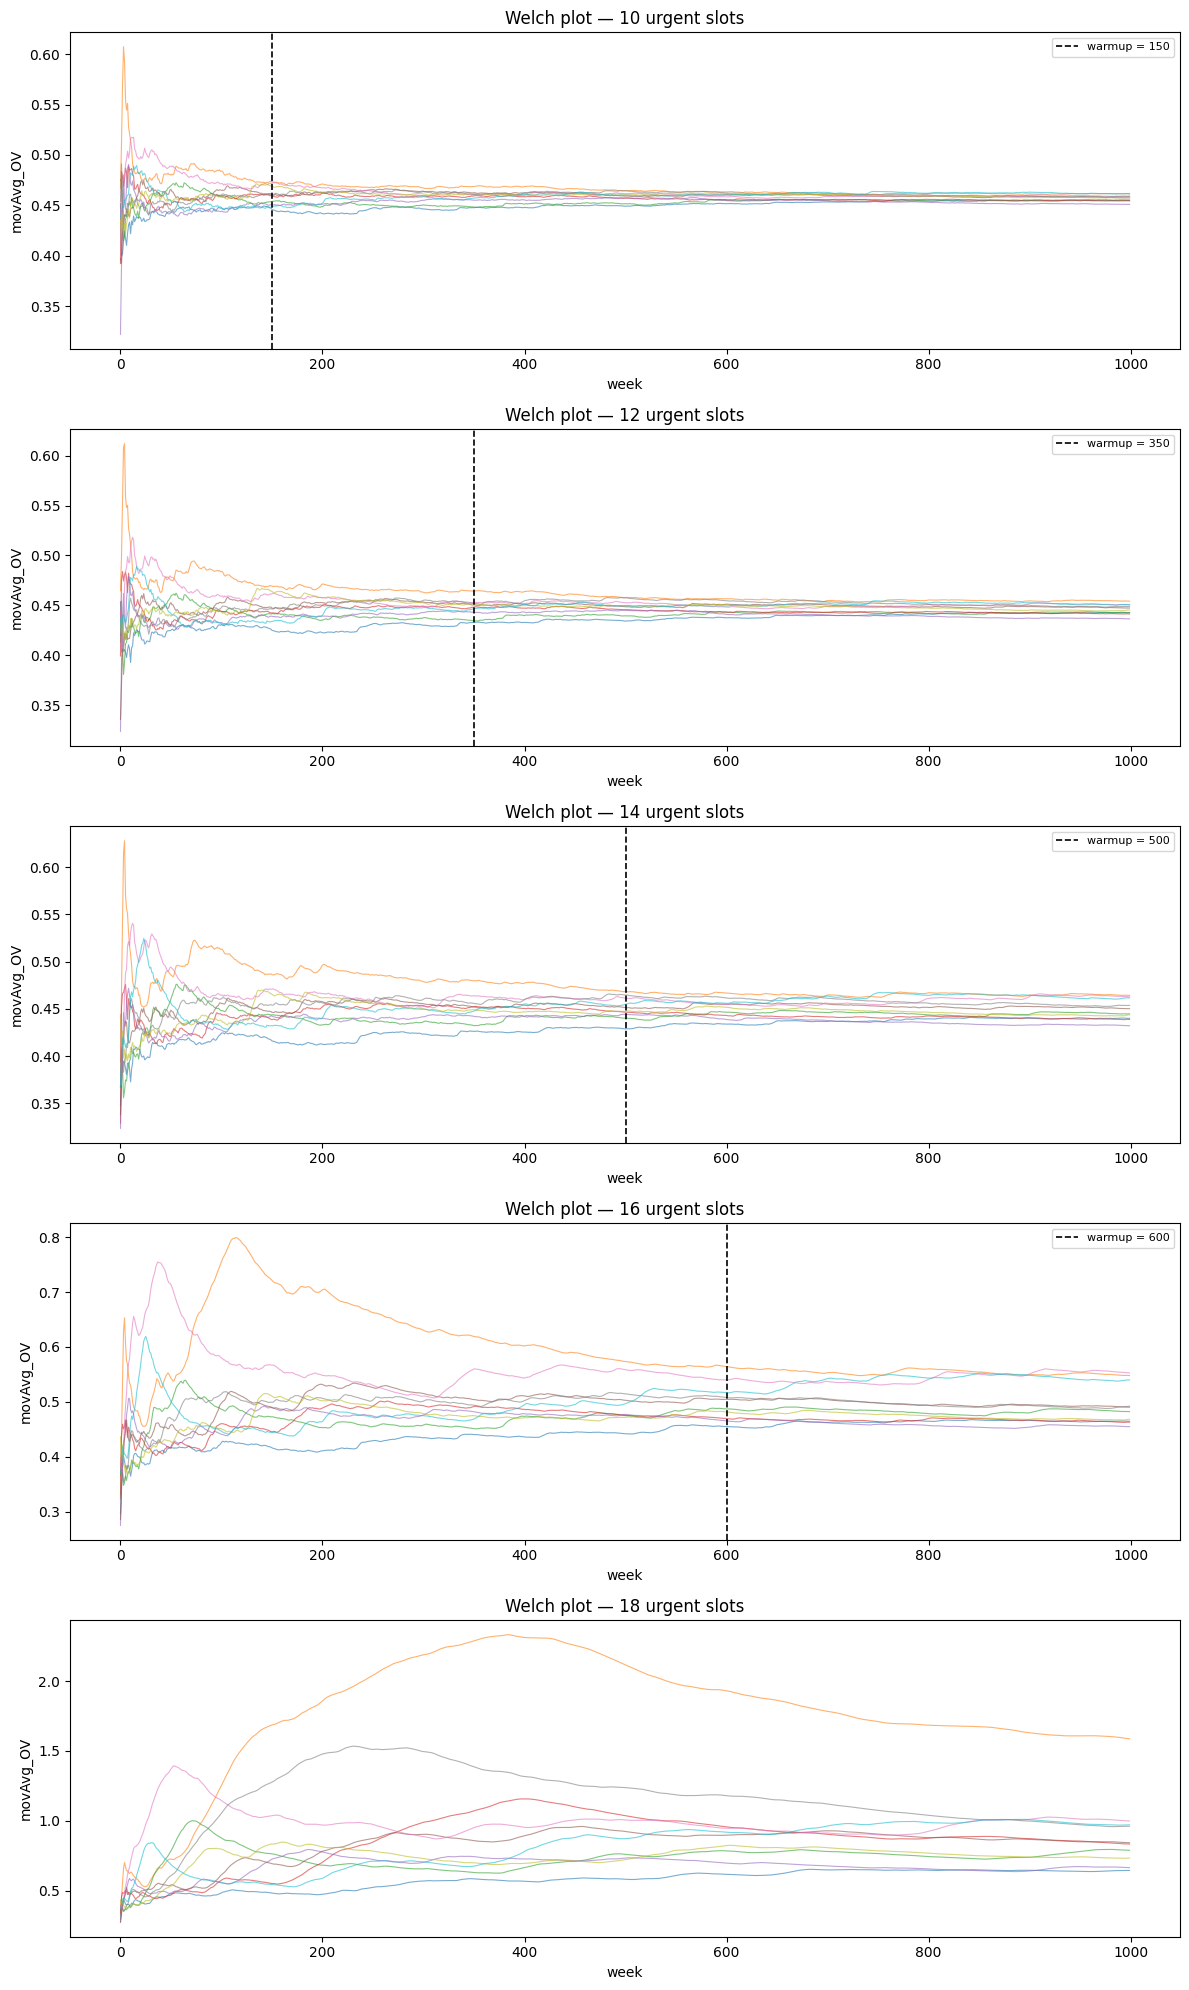

In [21]:
windows  = [2000]*5
slots    = list(range(10, 19, 2))
vlines   = [150, 350, 500, 600, None]

fig, axes = plt.subplots(len(slots), 1, figsize=(12, 4 * len(slots)), sharex=False)

for ax, (i_slot, slot_am) in zip(axes, enumerate(slots)):
    replications = results[slot_am]
    window = windows[i_slot]
    w = window // 2

    for r in replications:
        series = np.array(r[attr])
        n = len(series)
        stop = n - w
        ma = np.array([
            series[i - min(w, i) : i + min(w, i) + 1].mean()
            for i in range(stop)
        ])
        ax.plot(np.arange(stop), ma, linewidth=0.8, alpha=0.6)

    if vlines[i_slot] is not None:
        ax.axvline(x=vlines[i_slot], color='black', linestyle='--', linewidth=1.2, label=f'warmup = {vlines[i_slot]}')
        ax.legend(fontsize=8)

    ax.set_title(f'Welch plot — {slot_am} urgent slots')
    ax.set_xlabel('week')
    ax.set_ylabel(attr)

plt.tight_layout()
plt.show()


In [145]:
def mser(series):
    n = len(series)
    mser_vals = []
    for d in range(n - 10):      # need at least 10 obs remaining
        tail = series[d:]
        mser_vals.append(np.var(tail, ddof=1) / (n - d)**2)
    L = np.argmin(mser_vals)
    return L, mser_vals

# apply per replication, then take max across replications (conservative)
for slot_am in results:
    Ls = []
    for r in results[slot_am]:
        series = np.array(r['movAvg_OV'])
        L, _ = mser(series)
        Ls.append(L)
    print(f"slots={slot_am}: MSER warmup = {max(Ls)} weeks (max across replications)")


slots=10: MSER warmup = 25 weeks (max across replications)
slots=12: MSER warmup = 25 weeks (max across replications)
slots=14: MSER warmup = 27 weeks (max across replications)
slots=16: MSER warmup = 81 weeks (max across replications)
slots=18: MSER warmup = 140 weeks (max across replications)


# Part 3
Even more detail for a single replication

In [103]:
in_path = Path("../input/generated_input_files/input-S1-14.txt")

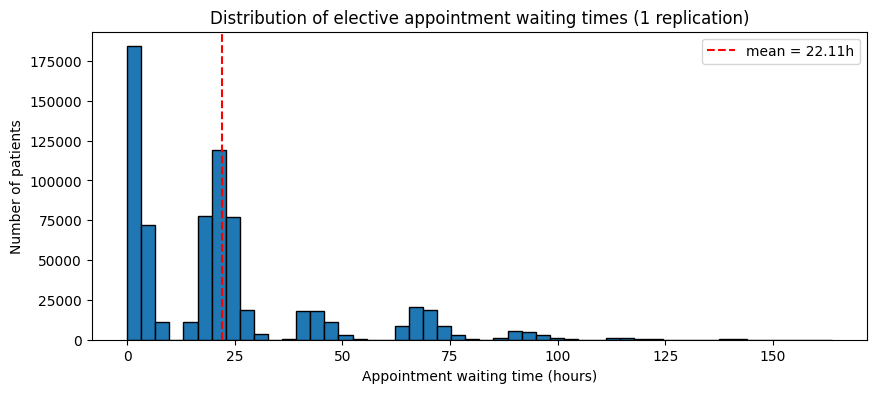

Min:  0.0h
Max:  163.7h
Mean: 22.1h


In [104]:
# collect all individual elective patient appWT values from one replication
sim2 = Simulation(in_path, W=5000, R=1, rule=1)
sim2.setWeekSchedule()
sim2.resetSystem()
random.seed(0)
sim2.generatePatients()
sim2.schedulePatients()

elective_waits = [
    p.getAppWT()
    for p in sim2.patients
    if p.patientType == 1 and p.scanWeek != -1
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(elective_waits, bins=50, edgecolor='black')
plt.xlabel('Appointment waiting time (hours)')
plt.ylabel('Number of patients')
plt.title('Distribution of elective appointment waiting times (1 replication)')
plt.axvline(sum(elective_waits)/len(elective_waits), color='red', linestyle='--', label=f'mean = {sum(elective_waits)/len(elective_waits):.2f}h')
plt.legend()
plt.show()

print(f"Min:  {min(elective_waits):.1f}h")
print(f"Max:  {max(elective_waits):.1f}h")
print(f"Mean: {sum(elective_waits)/len(elective_waits):.1f}h")

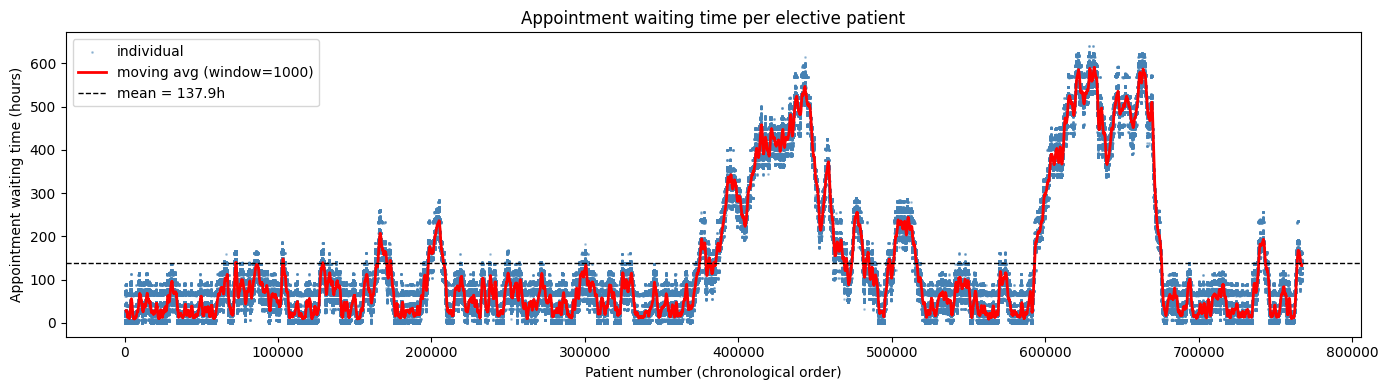

In [62]:
import numpy as np

elective_patients = [
    p for p in sim2.patients
    if p.patientType == 1 and p.scanWeek != -1
]

elective_patients.sort(key=lambda p: p.nr)

nrs   = [p.nr for p in elective_patients]
waits = [p.getAppWT() for p in elective_patients]

window = 1000
moving_avg = np.convolve(waits, np.ones(window)/window, mode='valid')
moving_avg_nrs = nrs[window-1:]  # align x-axis to end of each window

plt.figure(figsize=(14, 4))
plt.scatter(nrs, waits, alpha=0.4, s=1, color='steelblue', label='individual')
plt.plot(moving_avg_nrs, moving_avg, color='red', linewidth=2, label=f'moving avg (window={window})')
plt.axhline(sum(waits)/len(waits), color='black', linestyle='--', linewidth=1, label=f'mean = {sum(waits)/len(waits):.1f}h')
plt.xlabel('Patient number (chronological order)')
plt.ylabel('Appointment waiting time (hours)')
plt.title('Appointment waiting time per elective patient')
plt.legend()
plt.tight_layout()
plt.show()


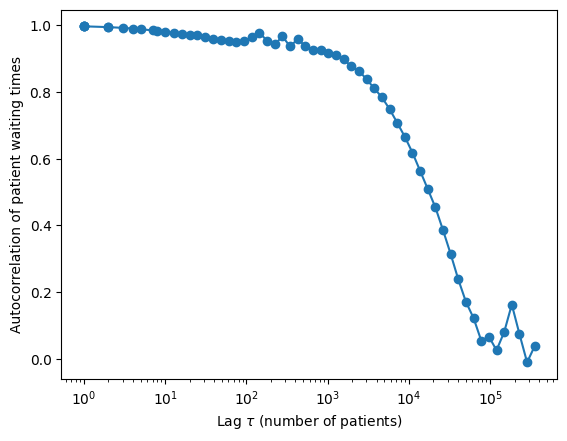

In [70]:
import numpy as np
import matplotlib.pyplot as plt

arr_waits = np.array(elective_waits)

def get_autocorrelation(waits, lag):
    if lag >= len(waits):
        return np.nan
    x = waits[:-lag]
    y = waits[lag:]
    return np.corrcoef(x, y)[0, 1]

tau_vals = np.logspace(0, np.log10(len(arr_waits)//20-1), num=60, dtype=int)
r_vals = [get_autocorrelation(arr_waits, tau) for tau in tau_vals]
plt.plot(tau_vals, r_vals, marker='o', linestyle='-')
plt.ylabel('Autocorrelation of patient waiting times')
plt.xlabel('Lag $\\tau$ (number of patients)')
plt.xscale('log')
plt.show()

In [75]:
# now get a single figure that combines it all

results = {}

def get_autocorrelation(waits, lag):
    if lag >= len(waits):
        return np.nan
    x = waits[:-lag]
    y = waits[lag:]
    return np.corrcoef(x, y)[0, 1]

for slot_am in range(10, 19, 2):
    in_path = Path(f"../input/generated_input_files/input-S1-{slot_am}.txt")
    # collect all individual elective patient appWT values from one replication
    sim2 = Simulation(in_path, W=30000, R=1, rule=1)
    sim2.setWeekSchedule()
    sim2.resetSystem()
    random.seed(0)
    sim2.generatePatients()
    sim2.schedulePatients()

    elective_waits = [
        p.getAppWT()
        for p in sim2.patients
        if p.patientType == 1 and p.scanWeek != -1
    ]

    arr_waits = np.array(elective_waits)
    tau_vals = np.logspace(0, np.log10(len(arr_waits)//20-1), num=60, dtype=int)
    r_vals = [get_autocorrelation(arr_waits, tau) for tau in tau_vals]
    results[slot_am] = (tau_vals, r_vals)

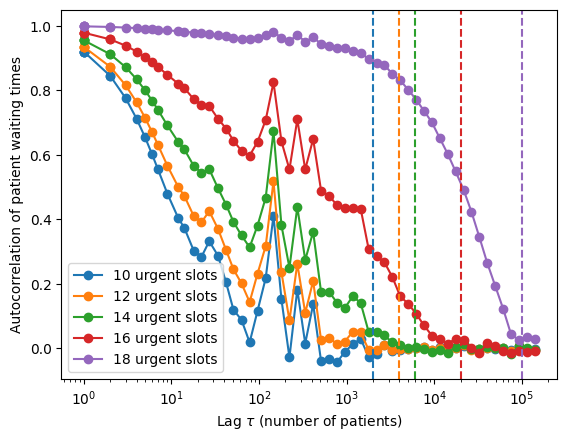

In [83]:
vlines = [2*10**3, 4*10**3, 6*10**3, 2*10**4, 10**5]

for slot_am in range(10, 19, 2):
    tau_vals, r_vals = results[slot_am]
    plt.plot(tau_vals[:-2], r_vals[:-2], marker='o', linestyle='-', label = f'{slot_am} urgent slots')
plt.ylabel('Autocorrelation of patient waiting times')
plt.xlabel('Lag $\\tau$ (number of patients)')
plt.xscale('log')
for i, x in enumerate(vlines):
    plt.axvline(x=x, color=f'C{i}', linestyle='--', alpha=1)

plt.legend()
plt.savefig('autocorrelation_plot.png', dpi=300)
plt.show()

In [97]:
#first is the 10 urgent slots-> 18 urgent slots
urgent_slots = np.array([10, 12, 14, 16, 18])
cutoff_lag_patients = np.array(vlines)
patients_per_week = np.array([160 - i for i in range(10, 19, 2)])
batch_size_weeks = (cutoff_lag_patients/patients_per_week)

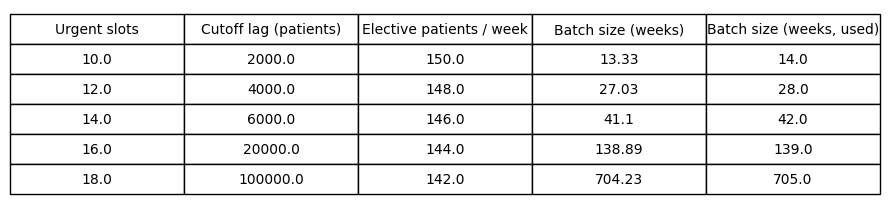

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

urgent_slots         = np.array([10, 12, 14, 16, 18])
cutoff_lag_patients  = np.array(vlines)
patients_per_week    = np.array([160 - i for i in range(10, 19, 2)])
batch_size_weeks     = cutoff_lag_patients / patients_per_week

df = pd.DataFrame({
    'Urgent slots':             urgent_slots,
    'Cutoff lag (patients)':    cutoff_lag_patients.astype(int),
    'Elective patients / week':          patients_per_week,
    'Batch size (weeks)':       np.round(batch_size_weeks, 2),
    'Batch size (weeks, used)':  np.ceil(batch_size_weeks).astype(int),
}).set_index('Urgent slots')

fig, ax = plt.subplots(figsize=(9, 2.2))
ax.axis('off')

tbl = ax.table(
    cellText=df.reset_index().values,
    colLabels=df.reset_index().columns,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

plt.tight_layout()
plt.savefig('batch_sizes_table.png', dpi=150, bbox_inches='tight')
plt.show()


In [93]:
in_path = Path("../input/generated_input_files/input-S1-16.txt")

with open(in_path) as f:
    all_lines = f.readlines()
s=''
for el in all_lines:
    s+=el
for c in ['0', '1', '2']:
    print(s.count(c), c)

32 0
144 1
16 2


# Part 4
Get real results now

# Idea for analysis

## Primary responses
- `elAppWT` — average appointment waiting time elective patients (hours)
- `urScanWT` — average scan waiting time urgent patients (hours)
- `OV = elAppWT/168 + urScanWT/9` — weighted objective value

## Factors for design
 - urgent slots per week
 - scheduling rule

 - timing stategies (where to put E and U slots)

## Method (per configuration)

### Warm up period
Get some estimates on the warmup period length, run 10(?) replications and plot when the values stabilize (also get some rough estimates for the variance and mean of relevant parameters)

### regenerative method/batch method
Cutting off the warmup period, generate one long simulation and do analysis here (based on regen/batch method)


In [32]:
import numpy as np
from scipy import stats
import helper


def run_batch_means(filename, rule, warmup, batch_size, n_batches):
    W_total = warmup + n_batches * batch_size

    sim = Simulation(filename, W_total, 1, rule)
    sim.setWeekSchedule()
    #the run with normal vars (non antithetic)
    sim.resetSystem()
    random.seed(0)
    helper.USE_ANTITHETIC=False
    sim.runOneSimulation()

    # extract post-warmup weekly values
    sl = slice(warmup, warmup + n_batches * batch_size)
    weekly1 = {
        'elAppWT':  np.array(sim.movingAvgElectiveAppWT[sl]),
        'elScanWT': np.array(sim.movingAvgElectiveScanWT[sl]),
        'urScanWT': np.array(sim.movingAvgUrgentScanWT[sl]),
        'OT':       np.array(sim.movingAvgOT[sl]),
    }

    #the run with normal vars (non antithetic)
    sim.resetSystem()
    random.seed(0)
    helper.USE_ANTITHETIC=True
    sim.runOneSimulation()

    # extract post-warmup weekly values
    sl = slice(warmup, warmup + n_batches * batch_size)
    weekly2 = {
        'elAppWT':  np.array(sim.movingAvgElectiveAppWT[sl]),
        'elScanWT': np.array(sim.movingAvgElectiveScanWT[sl]),
        'urScanWT': np.array(sim.movingAvgUrgentScanWT[sl]),
        'OT':       np.array(sim.movingAvgOT[sl]),
    }

    #weekly = {(weekly1[k] + weekly2[k])/2 for k in weekly1}  # sum the two runs to get antithetic estimates
    weekly = {k: (weekly1[k] + weekly2[k]) / 2 for k in weekly1}

    
    # cut into batches and average each
    batches = {}
    for key, arr in weekly.items():
        batches[key] = arr.reshape(n_batches, batch_size).mean(axis=1)
    batches['OV'] = batches['elAppWT'] / 168 + batches['urScanWT'] / 9

    # summarise: mean + 95% CI per metric
    summary = {}
    for key, arr in batches.items():
        mean = arr.mean()
        se   = arr.std(ddof=1) / np.sqrt(n_batches)
        hw   = stats.t.ppf(0.975, df=n_batches - 1) * se
        summary[key] = {'mean': mean, 'hw': hw, 'lower': mean - hw, 'upper': mean + hw}

    return summary, batches, weekly, weekly1, weekly2


In [33]:
summary, batches, weekly, weekly1, weekly2 = run_batch_means(
    filename   = '../input-S1-14.txt',
    rule       = 1,
    warmup     = 100,
    batch_size = 65,
    n_batches  = 60,
)

# print results table
print(f"{'metric':<12} {'mean':>10} {'95% CI':>20}")
print("-" * 45)
for k, v in summary.items():
    print(f"{k:<12} {v['mean']:>10.4f}   [{v['lower']:.4f}, {v['upper']:.4f}]")


metric             mean               95% CI
---------------------------------------------
elAppWT         22.6574   [21.5186, 23.7963]
elScanWT         0.0826   [0.0821, 0.0832]
urScanWT         2.8525   [2.8381, 2.8669]
OT               0.8002   [0.7871, 0.8134]
OV               0.4518   [0.4447, 0.4589]


In [34]:
np.var(weekly['elAppWT']), np.var(weekly1['elAppWT']), np.var(weekly2['elAppWT'])

(np.float64(125.48243275726703),
 np.float64(259.9984006172925),
 np.float64(274.4254824279774))

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

RULE_NAMES = {1: 'FCFS', 2: 'Bailey-Welch', 3: 'Blocking', 4: 'Benchmarking'}

# --- run all rules ---
all_results = []
for rule in [1, 2, 3, 4]:
    print(f"Running rule {rule} ({RULE_NAMES[rule]})...")
    summary, batches, weekly = run_batch_means(
        filename   = '../input-S1-14.txt',
        rule       = rule,
        warmup     = 100,
        batch_size = 65,
        n_batches  = 10,
    )
    row = {'rule': rule, 'rule_name': RULE_NAMES[rule]}
    for metric, vals in summary.items():
        row[metric]          = vals['mean']
        row[f'{metric}_hw']  = vals['hw']
        row[f'{metric}_lo']  = vals['lower']
        row[f'{metric}_hi']  = vals['upper']
    all_results.append(row)

df = pd.DataFrame(all_results)
print(df[['rule_name', 'elAppWT', 'urScanWT', 'OT', 'OV']].to_string(index=False))


Running rule 1 (FCFS)...
Running rule 2 (Bailey-Welch)...
Running rule 3 (Blocking)...
Running rule 4 (Benchmarking)...
   rule_name   elAppWT  urScanWT       OT       OV
        FCFS 19.266770  2.815119 0.778167 0.427474
Bailey-Welch 19.941558  2.746292 0.728934 0.423843
    Blocking 19.805587  2.804348 0.772118 0.429485
Benchmarking 19.339046  2.799418 0.768986 0.426160


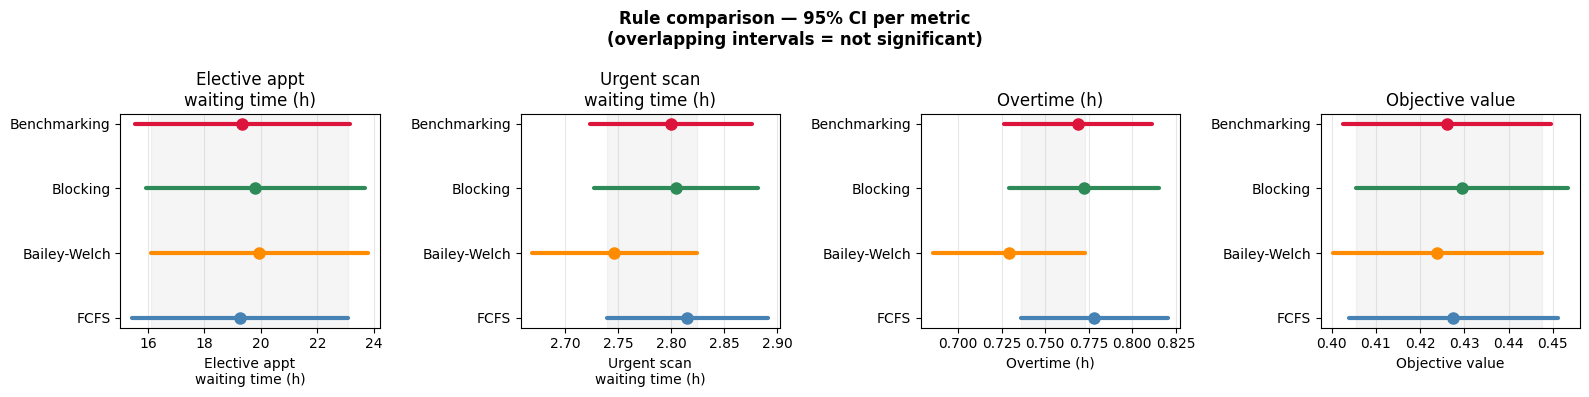

In [16]:
metrics = {
    'elAppWT':  'Elective appt\nwaiting time (h)',
    'urScanWT': 'Urgent scan\nwaiting time (h)',
    'OT':       'Overtime (h)',
    'OV':       'Objective value',
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for ax, (metric, label) in zip(axes, metrics.items()):
    for i, (_, row) in enumerate(df.iterrows()):
        ax.plot([row[f'{metric}_lo'], row[f'{metric}_hi']], [i, i],
                color=colors[i], linewidth=3, solid_capstyle='round')
        ax.plot(row[metric], i,
                'o', color=colors[i], markersize=8, zorder=5)

    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df['rule_name'])
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.grid(axis='x', alpha=0.3)
    # shade overlap region to make it obvious
    ax.axvspan(df[f'{metric}_lo'].max(), df[f'{metric}_hi'].min(),
               alpha=0.08, color='grey',
               label='overlap region' if metric == 'elAppWT' else '')

plt.suptitle('Rule comparison — 95% CI per metric\n(overlapping intervals = not significant)',
             fontweight='bold')
plt.tight_layout()
plt.show()


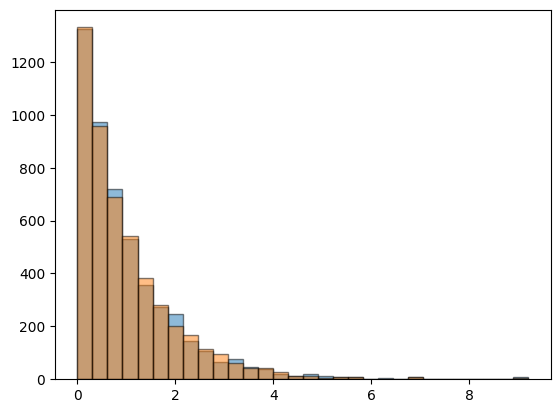

[[ 1.08573052 -0.66293902]
 [-0.66293902  1.03026473]]


In [17]:
import sys, random
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, '.')

import helper


random.seed(0)
vals1 = [helper.Exponential_distribution(1) for i in range(5000)]


random.seed(0)
helper.USE_ANTITHETIC = True
vals2 = [helper.Exponential_distribution(1) for i in range(5000)]

plt.hist(vals1, bins=30, alpha=0.5, label='standard', edgecolor='black')
plt.hist(vals2, bins=30, alpha=0.5, label='antithetic', edgecolor='black')
plt.show()

print(np.cov(vals1, vals2))

In [ ]:
# write the whole pipelines now (so even imports from 0)

In [7]:
import sys, random
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
sys.path.insert(0, '.')

from simulation import *
import helper

random.seed(0)



def run_batch_means(filename, rule, warmup, batch_size, n_batches, seed=0):
    W_total = warmup + n_batches * batch_size

    sim = Simulation(filename, W_total, 1, rule)
    sim.setWeekSchedule()
    #the run with normal vars (non antithetic)
    sim.resetSystem()
    random.seed(seed)
    helper.USE_ANTITHETIC=False
    sim.runOneSimulation()

    # extract post-warmup weekly values
    sl = slice(warmup, warmup + n_batches * batch_size)
    weekly1 = {
        'elAppWT':  np.array(sim.movingAvgElectiveAppWT[sl]),
        'elScanWT': np.array(sim.movingAvgElectiveScanWT[sl]),
        'urScanWT': np.array(sim.movingAvgUrgentScanWT[sl]),
        'OT':       np.array(sim.movingAvgOT[sl]),
    }

    #the run with normal vars (non antithetic)
    sim.resetSystem()
    random.seed(seed)
    helper.USE_ANTITHETIC=True
    sim.runOneSimulation()

    # extract post-warmup weekly values
    sl = slice(warmup, warmup + n_batches * batch_size)
    weekly2 = {
        'elAppWT':  np.array(sim.movingAvgElectiveAppWT[sl]),
        'elScanWT': np.array(sim.movingAvgElectiveScanWT[sl]),
        'urScanWT': np.array(sim.movingAvgUrgentScanWT[sl]),
        'OT':       np.array(sim.movingAvgOT[sl]),
    }

    #weekly = {(weekly1[k] + weekly2[k])/2 for k in weekly1}  # sum the two runs to get antithetic estimates
    weekly = {k: (weekly1[k] + weekly2[k]) / 2 for k in weekly1}

    
    # cut into batches and average each
    batches = {}
    for key, arr in weekly.items():
        batches[key] = arr.reshape(n_batches, batch_size).mean(axis=1)
    batches['OV'] = batches['elAppWT'] / 168 + batches['urScanWT'] / 9

    # summarise: mean + 95% CI per metric
    summary = {}
    for key, arr in batches.items():
        mean = arr.mean()
        se   = arr.std(ddof=1) / np.sqrt(n_batches)
        hw   = stats.t.ppf(0.975, df=n_batches - 1) * se
        summary[key] = {'mean': mean, 'hw': hw, 'lower': mean - hw, 'upper': mean + hw}

    return summary, batches, weekly, weekly1, weekly2

In [8]:
def estimate_warmup_period(filename, rule, Weeks, seed=0):
    sim = Simulation(filename, W=Weeks, R=1, rule=rule)
    sim.setWeekSchedule()
    sim.resetSystem()
    random.seed(seed)
    sim.generatePatients()
    sim.schedulePatients()

    elective_waits = [
        p.getAppWT()
        for p in sim.patients
        if p.patientType == 1 and p.scanWeek != -1
    ]

    arr_waits = np.array(elective_waits)

    def get_autocorrelation(waits, lag):
        if lag >= len(waits):
            return np.nan
        x = waits[:-lag]
        y = waits[lag:]
        return np.corrcoef(x, y)[0, 1]

    tau_vals = np.logspace(0, np.log10(len(arr_waits)//20-1), num=60, dtype=int)
    r_vals = [get_autocorrelation(arr_waits, tau) for tau in tau_vals]
    plt.plot(tau_vals, r_vals, marker='o', linestyle='-')
    plt.ylabel('Autocorrelation of patient waiting times')
    plt.xlabel('Lag $\\tau$ (number of patients)')
    plt.xscale('log')
    plt.show()

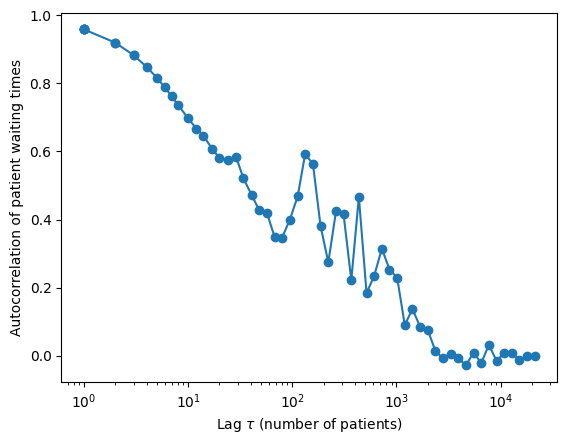

In [10]:
estimate_warmup_period(filename='../input-S1-14.txt', rule=1, Weeks=3000, seed=0)

(60, 3900)

In [12]:
summary, batches, weekly, weekly1, weekly2 = run_batch_means(
    filename   = '../input-S1-14.txt',
    rule       = 1,
    warmup     = 100,
    batch_size = 65,
    n_batches  = 60,
)

# print results table
print(f"{'metric':<12} {'mean':>10} {'95% CI':>20}")
print("-" * 45)
for k, v in summary.items():
    print(f"{k:<12} {v['mean']:>10.4f}   [{v['lower']:.4f}, {v['upper']:.4f}]")

metric             mean               95% CI
---------------------------------------------
elAppWT         22.6574   [21.5186, 23.7963]
elScanWT         0.0826   [0.0821, 0.0832]
urScanWT         2.8525   [2.8381, 2.8669]
OT               0.8002   [0.7871, 0.8134]
OV               0.4518   [0.4447, 0.4589]


In [18]:
import os
import pandas as pd

def save_results(filename, summary, weekly):
    # '../input-S1-14.txt'  ->  'S1-14'
    tag = os.path.splitext(os.path.basename(filename))[0].replace('input-', '')

    # --- summary.txt ---
    summary_path = f'summary-{tag}.txt'
    with open(summary_path, 'w') as f:
        f.write(f"{'metric':<12} {'mean':>10} {'hw':>10} {'lower':>10} {'upper':>10}\n")
        f.write("-" * 55 + "\n")
        for metric, v in summary.items():
            f.write(f"{metric:<12} {v['mean']:>10.4f} {v['hw']:>10.4f} "
                    f"{v['lower']:>10.4f} {v['upper']:>10.4f}\n")

    # --- output.csv (weekly data) ---
    output_path = f'output-{tag}.csv'
    pd.DataFrame(weekly).rename_axis('week').to_csv(output_path, float_format='%.6f')

    print(f"Saved {summary_path} and {output_path}")


In [19]:
summary, batches, weekly, w1, w2 = run_batch_means('../input-S1-14.txt', rule=1,
                                           warmup=100, batch_size=65, n_batches=60)
save_results('../input-S1-14.txt', summary, weekly)


FileNotFoundError: [Errno 2] No such file or directory: '../input-S1-14.txt'